In [1]:
# Імпорт бібліотек
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 7 # фіксуємо random state
np.random.seed(RANDOM_STATE)


In [2]:
# посилання на дані
DATA_URL = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
try:
    df_raw = pd.read_csv(DATA_URL) # завантаження з інтернету
except Exception:
    df_raw = pd.read_csv("insurance.csv") # локальний файл

df = df_raw.copy() # копія даних
print("Розмір набору даних:", df.shape)
df.head()


Розмір набору даних: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info() # інформація про дані


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
df.describe(include="all").T # описова статистика


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [5]:
missing = df.isna().sum() # пропущені значення
duplicates = df.duplicated().sum() # дублікати
print("Пропущені значення:\n", missing)
print("\nКількість дублікатів:", duplicates)


Пропущені значення:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Кількість дублікатів: 1


In [6]:
df[df.duplicated(keep=False)] # рядки-дублікати


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [7]:
df = df.drop_duplicates().reset_index(drop=True) # видаляємо дублікати
print("Розмір після видалення дублікатів:", df.shape)


Розмір після видалення дублікатів: (1337, 7)


In [8]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75) # квартилі
    iqr = q3 - q1 # міжквартильний розмах
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr # межі викидів
    mask = (series < low) | (series > high) # маска викидів
    return mask, low, high

for col in ["age", "bmi", "children", "charges"]:
    mask, low, high = iqr_outliers(df[col]) # рахуємо межі та маску для колонки
    print(f"{col}: межі [{low:.1f}, {high:.1f}], викидів: {mask.sum()} ({mask.mean()*100:.1f}%)")


age: межі [-9.0, 87.0], викидів: 0 (0.0%)
bmi: межі [13.7, 47.3], викидів: 9 (0.7%)
children: межі [-3.0, 5.0], викидів: 0 (0.0%)
charges: межі [-13120.7, 34524.8], викидів: 139 (10.4%)


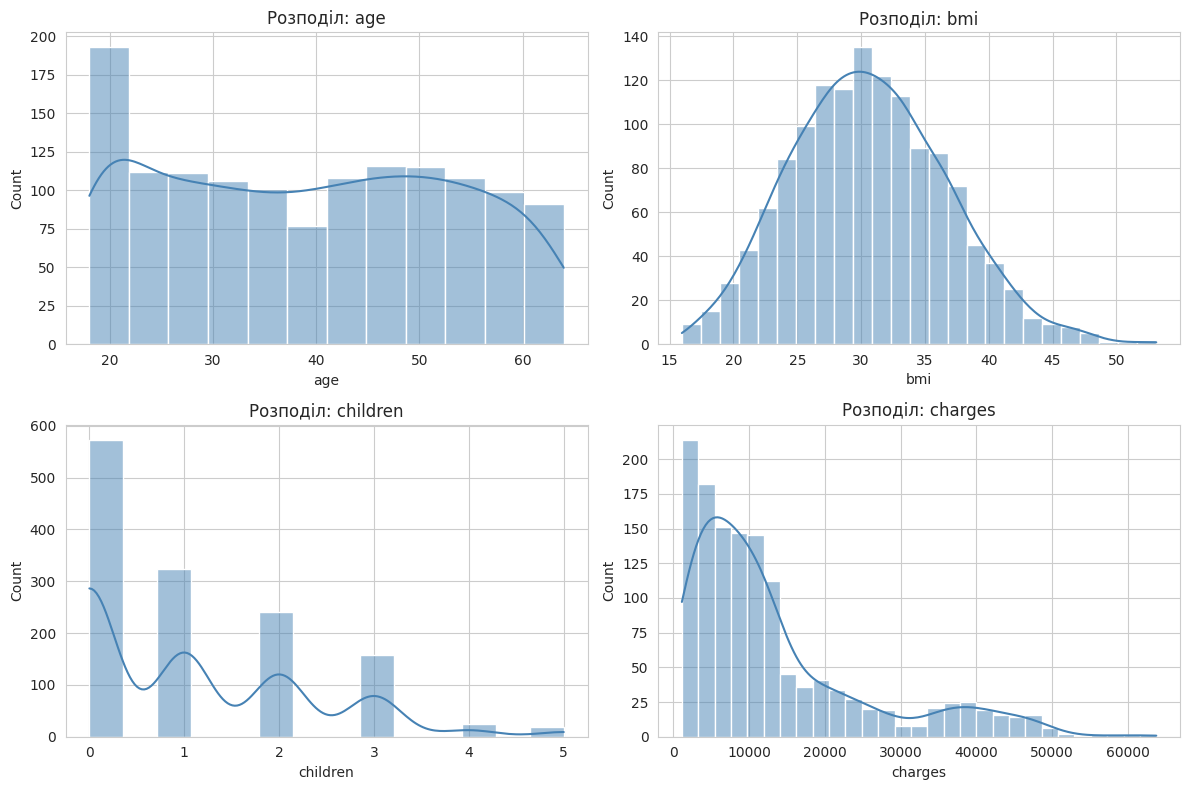

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8)) # сітка гістограм
for ax, col in zip(axes.ravel(), ["age", "bmi", "children", "charges"]):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue") # гістограма
    ax.set_title(f"Розподіл: {col}")
plt.tight_layout()
plt.show()


/tmp/ipykernel_100/3787099415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette="Set2")   # частоти категорій
/tmp/ipykernel_100/3787099415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette="Set2")   # частоти категорій
/tmp/ipykernel_100/3787099415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette="Set2")   # частоти категорій


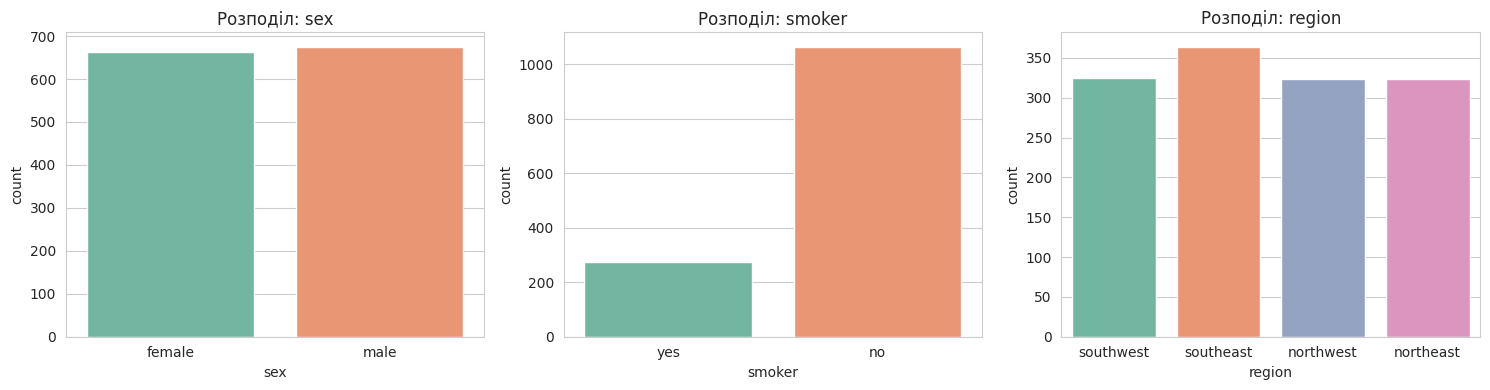

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["sex", "smoker", "region"]):
    sns.countplot(data=df, x=col, ax=ax, palette="Set2") # частоти категорій
    ax.set_title(f"Розподіл: {col}")
plt.tight_layout()
plt.show()


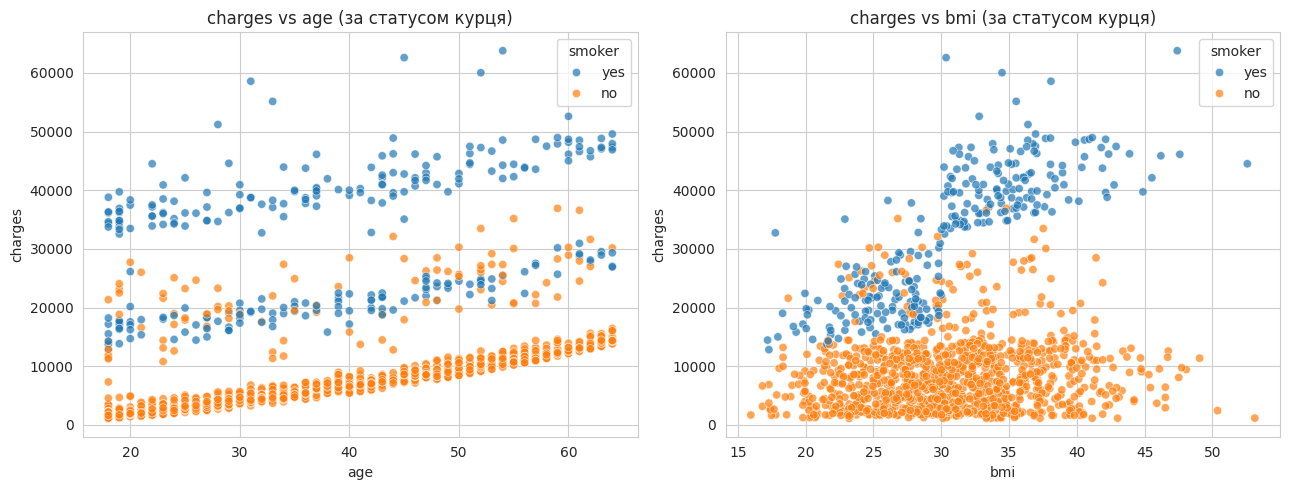

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.7, ax=axes[0]) # витрати за віком
axes[0].set_title("charges vs age (за статусом курця)")
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.7, ax=axes[1]) # витрати за ІМТ
axes[1].set_title("charges vs bmi (за статусом курця)")
plt.tight_layout()
plt.show()


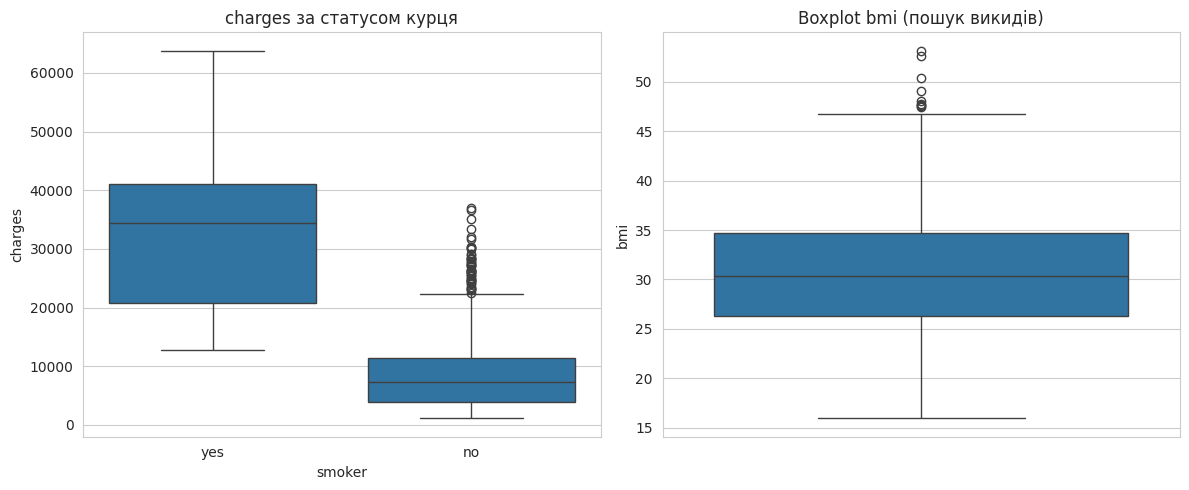

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="smoker", y="charges", ax=axes[0]) # витрати курців і некурців
axes[0].set_title("charges за статусом курця")
sns.boxplot(data=df, y="bmi", ax=axes[1]) # розподіл ІМТ
axes[1].set_title("Boxplot bmi (пошук викидів)")
plt.tight_layout()
plt.show()


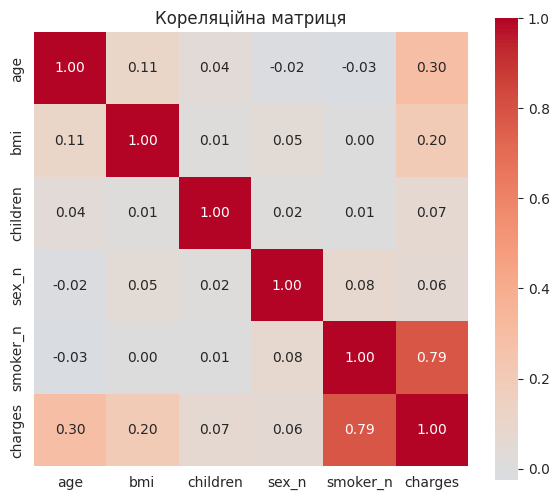

In [13]:
df_corr = df.copy()
df_corr["sex_n"] = df_corr["sex"].map({"male": 1, "female": 0}) # тимчасове числове кодування
df_corr["smoker_n"] = df_corr["smoker"].map({"yes": 1, "no": 0}) # для кореляції
corr_cols = ["age", "bmi", "children", "sex_n", "smoker_n", "charges"]
corr_matrix = df_corr[corr_cols].corr() # матриця кореляцій

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Кореляційна матриця")
plt.show()


In [14]:
data = df.copy()
data["sex"] = data["sex"].map({"male": 1, "female": 0}) # кодування статі
data["smoker"] = data["smoker"].map({"yes": 1, "no": 0}) # кодування smoker
data = pd.get_dummies(data, columns=["region"], drop_first=True) # one-hot кодування регіону
data["smoker_bmi"] = data["smoker"] * data["bmi"] # взаємодія smoker і BMI

bool_cols = data.select_dtypes(include="bool").columns # bool-стовпці
data[bool_cols] = data[bool_cols].astype(int) # True/False у 1/0

data.head()


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,smoker_bmi
0,19,0,27.900,0,1,16884.92400,0,0,1,27.9
1,18,1,33.770,1,0,1725.55230,0,1,0,0.0
2,28,1,33.000,3,0,4449.46200,0,1,0,0.0
3,33,1,22.705,0,0,21984.47061,1,0,0,0.0
4,32,1,28.880,0,0,3866.85520,1,0,0,0.0


In [15]:
X = data.drop(columns=["charges"]) # ознаки
y = data["charges"] # цільова змінна

# розділяємо train і test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (935, 9)  Test: (402, 9)


In [16]:
scaler = StandardScaler() # масштабування
X_train_scaled = scaler.fit_transform(X_train) # масштабування train
X_test_scaled = scaler.transform(X_test) # масштабування test

feature_names = X.columns.tolist()


In [17]:
results = {} # результати моделей

def evaluate(name, model, X_tr, y_tr, X_te, y_te, predict_fn=None, fit_time=None):
    # рахуємо метрики
    if predict_fn is None: # без власної функції прогнозу
        pred_tr = model.predict(X_tr)
        pred_te = model.predict(X_te)
    else:
        pred_tr = predict_fn(X_tr)
        pred_te = predict_fn(X_te)

    metrics = {
        "MAE_train": mean_absolute_error(y_tr, pred_tr),
        "RMSE_train": np.sqrt(mean_squared_error(y_tr, pred_tr)),
        "R2_train": r2_score(y_tr, pred_tr),
        "MAE_test": mean_absolute_error(y_te, pred_te),
        "RMSE_test": np.sqrt(mean_squared_error(y_te, pred_te)),
        "R2_test": r2_score(y_te, pred_te),
        "fit_time_s": fit_time,
    }
    results[name] = metrics # зберігаємо результати
    return metrics, pred_te


In [18]:
t0 = time.time() # час навчання
lr_sklearn = LinearRegression() # лінійна регресія
lr_sklearn.fit(X_train_scaled, y_train) # навчання
fit_time_lr = time.time() - t0

metrics_lr, pred_lr = evaluate("Sklearn_LinearRegression", lr_sklearn,
                                X_train_scaled, y_train, X_test_scaled, y_test,
                                fit_time=fit_time_lr)
metrics_lr


{'MAE_train': 2719.2670378354683,
 'RMSE_train': np.float64(4678.835546156952),
 'R2_train': 0.8516499223097356,
 'MAE_test': 2999.114212866282,
 'RMSE_test': np.float64(5184.20497239414),
 'R2_test': 0.813530585592064,
 'fit_time_s': 0.0013561248779296875}

In [19]:
param_grid = {
    "Lasso": {"alpha": [0.01, 0.1, 1, 5, 10, 50]}, # параметри Lasso
    "Ridge": {"alpha": [0.01, 0.1, 1, 5, 10, 50, 100]}, # параметри Ridge
    "ElasticNet": {"alpha": [0.01, 0.1, 1, 5, 10], "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]},
}
models = {"Lasso": Lasso(max_iter=10000), "Ridge": Ridge(), "ElasticNet": ElasticNet(max_iter=10000)}

best_reg_models = {}
for name, model in models.items():
    grid = GridSearchCV(model, param_grid[name], cv=5, scoring="neg_root_mean_squared_error") # 5-fold CV
    grid.fit(X_train_scaled, y_train) # підбір параметрів
    best_reg_models[name] = grid.best_estimator_ # зберігаємо модель
    print(f"{name}: best_params={grid.best_params_}, CV_RMSE={-grid.best_score_:.2f}")


Lasso: best_params={'alpha': 10}, CV_RMSE=4740.13
Ridge: best_params={'alpha': 1}, CV_RMSE=4739.17


ElasticNet: best_params={'alpha': 0.01, 'l1_ratio': 0.9}, CV_RMSE=4738.87


In [20]:
for name, model in best_reg_models.items():
    t0 = time.time()
    model.fit(X_train_scaled, y_train) # навчання на train
    fit_time = time.time() - t0
    evaluate(f"Sklearn_{name}", model, X_train_scaled, y_train, X_test_scaled, y_test, fit_time=fit_time)

pd.DataFrame(results).T[["RMSE_train", "RMSE_test", "R2_test"]]


,RMSE_train,RMSE_test,R2_test
Sklearn_LinearRegression,4678.835546,5184.204972,0.813531
Sklearn_Lasso,4680.038440,5174.925759,0.814198
Sklearn_Ridge,4681.101053,5174.434639,0.814233
Sklearn_ElasticNet,4680.832393,5174.906726,0.814199


In [21]:
t0 = time.time()
xgb_base = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1) # базова модель
xgb_base.fit(X_train_scaled, y_train)
fit_time_xgb_base = time.time() - t0
evaluate("XGBoost_baseline", xgb_base, X_train_scaled, y_train, X_test_scaled, y_test, fit_time=fit_time_xgb_base)


({'MAE_train': 383.8620959621658,
  'RMSE_train': np.float64(795.6595856122588),
  'R2_train': 0.9957099059293483,
  'MAE_test': 2997.6396248322594,
  'RMSE_test': np.float64(5469.737172502601),
  'R2_test': 0.7924244509560618,
  'fit_time_s': 0.04373979568481445},
 array([11162.455  ,  9373.467  ,  1854.5549 ,  7803.103  ,  4043.5876 ,
         1379.7927 , 15231.675  , 10759.511  ,  2234.411  , 12915.482  ,
         6988.8237 ,  6696.8745 , 10195.374  ,  5544.931  ,  5649.555  ,
         2147.2104 , 25662.49   , 13593.28   , 10655.26   , 19331.895  ,
        39443.39   , 20248.049  , 34918.258  ,  5099.6416 ,  7250.8228 ,
        12542.006  ,  8189.899  , 17135.248  ,  6881.3257 ,  3574.9863 ,
         6526.786  , 19007.95   ,  7142.5903 , 37828.37   , 15564.489  ,
          805.7569 , 39170.72   ,  4155.0522 , 40914.28   ,  9692.314  ,
        13228.019  ,  6129.2393 ,  8292.354  , 11342.528  ,  3768.0525 ,
         6005.351  ,  3239.3906 , 54575.316  ,  2481.6785 , 13880.912  ,
    

In [22]:
xgb_param_dist = {
    "n_estimators": [100, 200, 300, 500], # кількість дерев
    "max_depth": [2, 3, 4, 5, 6], # глибина дерева
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2], # темп навчання
    "subsample": [0.6, 0.8, 1.0], # частка вибірки
    "colsample_bytree": [0.6, 0.8, 1.0], # частка ознак
    "reg_lambda": [0.1, 1, 5, 10], # L2-регуляризація
}

random_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=30, cv=5, scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=-1,
)
random_search.fit(X_train_scaled, y_train) # random search, 5-fold CV
print("Найкращі параметри XGBoost:", random_search.best_params_)


Найкращі параметри XGBoost: {'subsample': 0.8, 'reg_lambda': 1, 'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


In [23]:
t0 = time.time()
xgb_best = random_search.best_estimator_ # найкраща модель
xgb_best.fit(X_train_scaled, y_train) # навчання на train
fit_time_xgb = time.time() - t0
metrics_xgb, pred_xgb = evaluate("XGBoost_tuned", xgb_best, X_train_scaled, y_train,
                                  X_test_scaled, y_test, fit_time=fit_time_xgb)
metrics_xgb


{'MAE_train': 2224.7799826774067,
 'RMSE_train': np.float64(4114.044100475207),
 'R2_train': 0.8853035166743479,
 'MAE_test': 2556.3378727178556,
 'RMSE_test': np.float64(4725.890542422006),
 'R2_test': 0.8450432155605797,
 'fit_time_s': 0.022557497024536133}

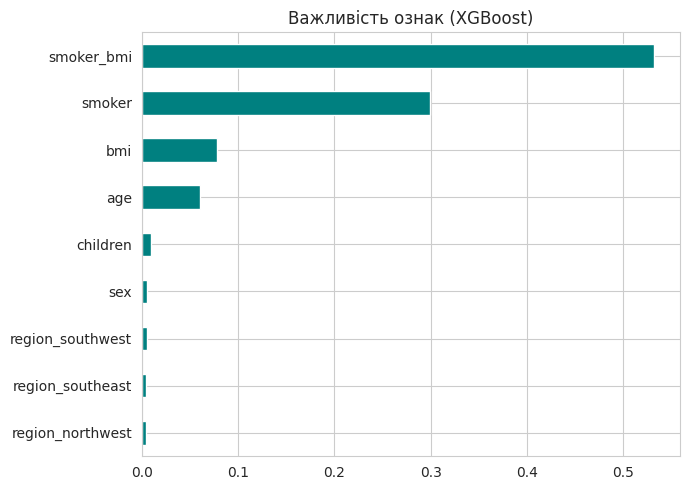

In [24]:
importances = pd.Series(xgb_best.feature_importances_, index=feature_names) # важливість ознак
importances.sort_values().plot(kind="barh", figsize=(7, 5), color="teal")
plt.title("Важливість ознак (XGBoost)")
plt.tight_layout()
plt.show()


In [25]:
class LinearRegressionGD:
    # власна лінійна регресія

    def __init__(self, lr=0.01, n_iters=2000, l2=0.0):
        self.lr = lr
        self.n_iters = n_iters
        self.l2 = l2
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for _ in range(self.n_iters):
            y_pred = X @ self.weights + self.bias # поточний прогноз
            error = y_pred - y # похибка

            grad_w = (2 / n_samples) * (X.T @ error) + 2 * self.l2 * self.weights # градієнт ваг
            grad_b = (2 / n_samples) * np.sum(error) # градієнт bias

            self.weights -= self.lr * grad_w # оновлення ваг
            self.bias -= self.lr * grad_b # оновлення bias

            mse = np.mean(error ** 2) # MSE
            self.loss_history.append(mse) # зберігаємо MSE

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.weights + self.bias


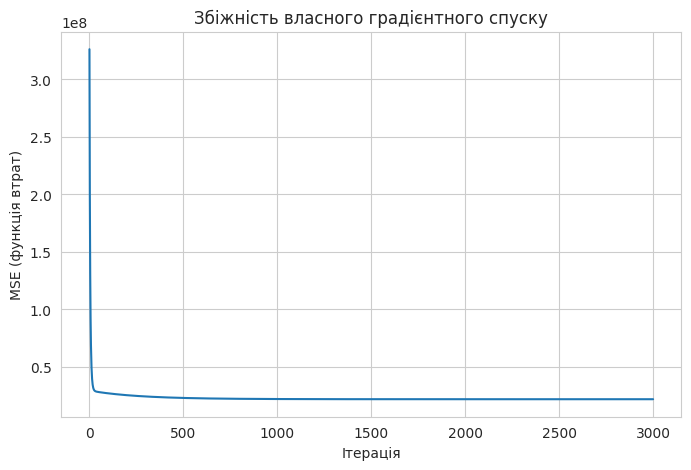

In [26]:
vanilla_model = LinearRegressionGD(lr=0.05, n_iters=3000, l2=0.0) # модель без L2
t0 = time.time()
vanilla_model.fit(X_train_scaled, y_train.values) # навчання
fit_time_vanilla = time.time() - t0

plt.plot(vanilla_model.loss_history) # графік MSE
plt.xlabel("Ітерація")
plt.ylabel("MSE (функція втрат)")
plt.title("Збіжність власного градієнтного спуску")
plt.show()


In [27]:
metrics_vanilla, pred_vanilla = evaluate(
    "Vanilla_GD", vanilla_model, X_train_scaled, y_train, X_test_scaled, y_test,
    predict_fn=vanilla_model.predict, fit_time=fit_time_vanilla
)
metrics_vanilla


{'MAE_train': 2719.375544675576,
 'RMSE_train': np.float64(4678.84411219773),
 'R2_train': 0.8516493791087764,
 'MAE_test': 2998.7170502294052,
 'RMSE_test': np.float64(5183.5081748692655),
 'R2_test': 0.8135807081065936,
 'fit_time_s': 0.05307340621948242}

In [28]:
compare_coefs = pd.DataFrame({
    "feature": feature_names,
    "sklearn_coef": lr_sklearn.coef_,
    "vanilla_coef": vanilla_model.weights,
})
compare_coefs["abs_diff"] = (compare_coefs["sklearn_coef"] - compare_coefs["vanilla_coef"]).abs()
print(f"Зсув (bias): sklearn={lr_sklearn.intercept_:.2f}, vanilla={vanilla_model.bias:.2f}")
compare_coefs


Зсув (bias): sklearn=13366.22, vanilla=13366.22


,feature,sklearn_coef,vanilla_coef,abs_diff
0,age,3753.809732,3753.675759,0.133973
1,sex,-215.385085,-215.104465,0.280619
2,bmi,207.102174,211.852360,4.750185
3,children,597.738059,597.894787,0.156728
4,smoker,-8938.987616,-8893.352761,45.634855
5,region_northwest,-386.245985,-386.114395,0.131590
6,region_southeast,-639.995366,-640.069678,0.074311
7,region_southwest,-598.867114,-598.432644,0.434470
8,smoker_bmi,19158.413377,19112.578968,45.834408


In [29]:
best_alpha_vanilla, best_rmse_vanilla = None, np.inf
for l2 in [0.0, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]: # перебір L2
    m = LinearRegressionGD(lr=0.05, n_iters=3000, l2=l2)
    m.fit(X_train_scaled, y_train.values)
    pred = m.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    if rmse < best_rmse_vanilla: # зберігаємо найкращий
        best_rmse_vanilla, best_alpha_vanilla, best_model_vanilla = rmse, l2, m

print(f"Найкраще l2={best_alpha_vanilla}, test RMSE={best_rmse_vanilla:.2f}")
fit_time_vanilla_reg = fit_time_vanilla # час навчання
evaluate("Vanilla_GD_L2", best_model_vanilla, X_train_scaled, y_train, X_test_scaled, y_test,
          predict_fn=best_model_vanilla.predict, fit_time=fit_time_vanilla_reg)


Найкраще l2=0.001, test RMSE=5174.60


({'MAE_train': 2724.513609248938,
  'RMSE_train': np.float64(4681.0177234692155),
  'R2_train': 0.8515115110907623,
  'MAE_test': 2995.6555927236896,
  'RMSE_test': np.float64(5174.597737877307),
  'R2_test': 0.8142210657966749,
  'fit_time_s': 0.05307340621948242},
 array([12242.69892266, 11463.04919177,  2171.09359882,  8832.56121946,
         6388.750659  ,  2676.44175902, 13830.36041458, 11088.70083504,
         4173.69379446, 12175.56931043,  4602.90003233,  6245.78201798,
         3848.77264543,  6210.57503785,  8088.25832016,  3471.69476636,
        29231.40313269, 13738.51917684, 11793.84633045,  9251.99759078,
        33083.96978525, 17344.9025111 , 37049.45104394,  6898.76722161,
         5447.88023857, 12226.13769958,  8498.52535141, 11984.71709172,
        10623.20793613,  2866.83021368,  8873.07546735, 20937.71899035,
         4411.21154681, 35207.01654062, 11583.15401068,  1578.91190329,
        36281.06581604,  5003.3452308 , 59424.23185723, 10997.22835877,
         4312

In [30]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("RMSE_test")
results_df


,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,fit_time_s
XGBoost_tuned,2224.779983,4114.044100,0.885304,2556.337873,4725.890542,0.845043,0.022557
Sklearn_Ridge,2724.748153,4681.101053,0.851506,2995.708341,5174.434639,0.814233,0.000670
Vanilla_GD_L2,2724.513609,4681.017723,0.851512,2995.655593,5174.597738,0.814221,0.053073
Sklearn_ElasticNet,2724.253094,4680.832393,0.851523,2995.812919,5174.906726,0.814199,0.001727
Sklearn_Lasso,2722.154286,4680.038440,0.851574,2995.974529,5174.925759,0.814198,0.001311
Vanilla_GD,2719.375545,4678.844112,0.851649,2998.717050,5183.508175,0.813581,0.053073
Sklearn_LinearRegression,2719.267038,4678.835546,0.851650,2999.114213,5184.204972,0.813531,0.001356
XGBoost_baseline,383.862096,795.659586,0.995710,2997.639625,5469.737173,0.792424,0.043740


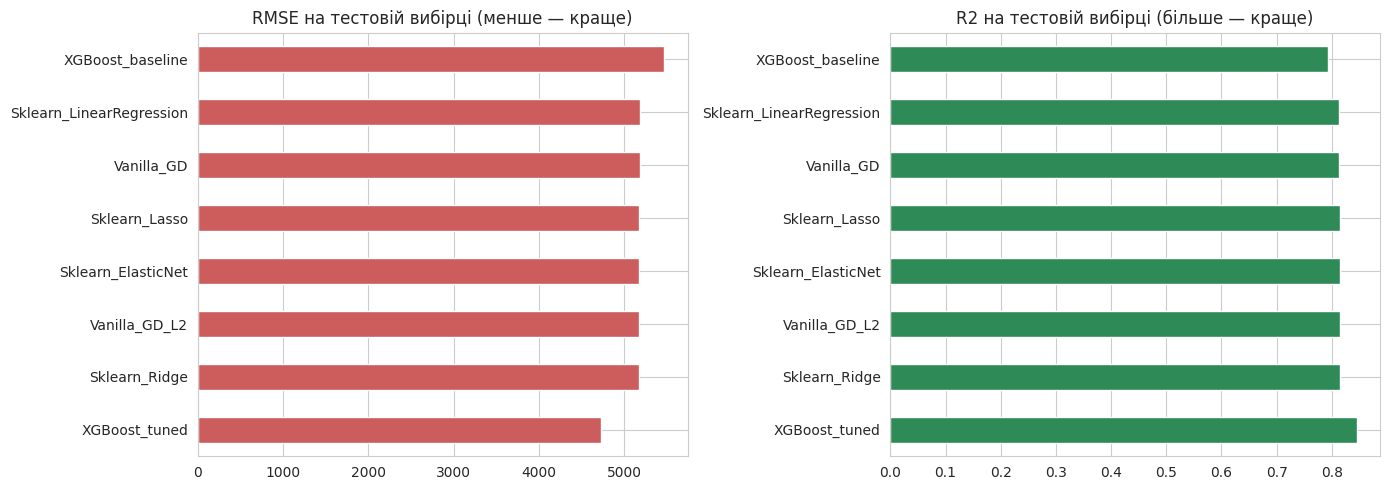

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results_df["RMSE_test"].plot(kind="barh", ax=axes[0], color="indianred") # RMSE на test
axes[0].set_title("RMSE на тестовій вибірці (менше — краще)")
results_df["R2_test"].plot(kind="barh", ax=axes[1], color="seagreen") # R2 на test
axes[1].set_title("R2 на тестовій вибірці (більше — краще)")
plt.tight_layout()
plt.show()


In [32]:
best_sklearn_name = results_df.drop(index=["XGBoost_baseline", "XGBoost_tuned", "Vanilla_GD", "Vanilla_GD_L2"]).index[0]
best_sklearn_model = {**{"Sklearn_LinearRegression": lr_sklearn}, **{f"Sklearn_{k}": v for k, v in best_reg_models.items()}}[best_sklearn_name]
print("Найкраща лінійна scikit-learn модель:", best_sklearn_name)

pred_ensemble_test = (
    best_sklearn_model.predict(X_test_scaled) + # прогноз лінійної моделі
    xgb_best.predict(X_test_scaled) + # прогноз XGBoost
    vanilla_model.predict(X_test_scaled) # прогноз власної моделі
) / 3 # середній прогноз

pred_ensemble_train = (
    best_sklearn_model.predict(X_train_scaled) +
    xgb_best.predict(X_train_scaled) +
    vanilla_model.predict(X_train_scaled)
) / 3

results["Ensemble_avg3"] = {
    "MAE_train": mean_absolute_error(y_train, pred_ensemble_train),
    "RMSE_train": np.sqrt(mean_squared_error(y_train, pred_ensemble_train)),
    "R2_train": r2_score(y_train, pred_ensemble_train),
    "MAE_test": mean_absolute_error(y_test, pred_ensemble_test),
    "RMSE_test": np.sqrt(mean_squared_error(y_test, pred_ensemble_test)),
    "R2_test": r2_score(y_test, pred_ensemble_test),
    "fit_time_s": None,
}
pd.DataFrame(results).T.sort_values("RMSE_test")


Найкраща лінійна scikit-learn модель: Sklearn_Ridge


,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,fit_time_s
XGBoost_tuned,2224.779983,4114.044100,0.885304,2556.337873,4725.890542,0.845043,0.022557
Ensemble_avg3,2495.484364,4376.543298,0.870200,2798.181970,4926.565234,0.831604,NaN
Sklearn_Ridge,2724.748153,4681.101053,0.851506,2995.708341,5174.434639,0.814233,0.000670
Vanilla_GD_L2,2724.513609,4681.017723,0.851512,2995.655593,5174.597738,0.814221,0.053073
Sklearn_ElasticNet,2724.253094,4680.832393,0.851523,2995.812919,5174.906726,0.814199,0.001727
Sklearn_Lasso,2722.154286,4680.038440,0.851574,2995.974529,5174.925759,0.814198,0.001311
Vanilla_GD,2719.375545,4678.844112,0.851649,2998.717050,5183.508175,0.813581,0.053073
Sklearn_LinearRegression,2719.267038,4678.835546,0.851650,2999.114213,5184.204972,0.813531,0.001356
XGBoost_baseline,383.862096,795.659586,0.995710,2997.639625,5469.737173,0.792424,0.043740
